Importing some Libraries and connecting to drive

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\yashv\OneDrive\Desktop\PROJECTS\zomato-project\zomato.csv")


EDA(Exploratory Data Analysis)

In [26]:
print("Starting with EDA")

Starting with EDA


In [27]:

print("Top 5 rows")
print(df.head(3))
print("Last 5 rows")
print(df.tail(3))
print(df.dtypes)

Top 5 rows
                                                 url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   

                                             address             name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...            Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...   Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...  San Churro Cafe   

  online_order book_table   rate  votes                           phone  \
0          Yes        Yes  4.1/5    775  080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5    787                    080 41714161   
2          Yes         No  3.8/5    918                  +91 9663487993   

       location            rest_type  \
0  Banashankari        Casual Dining   
1  Banashankari        Casual Dining   
2  Banashankari  Cafe, Casual Dining   

         

Check for null values

In [28]:
print('No of null values')
null=df.isnull().sum()
print(null)

No of null values
url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64


Handling Missing values

In [29]:
# 1. Define a helper function to clean text numbers and fill with the average
def clean_numeric_column(column):
    # Remove common string garbage (like '/5' or commas in cost like '1,200')
    clean_str = column.astype(str).str.replace('/5', '', regex=False)
    clean_str = clean_str.str.replace(',', '', regex=False).str.strip()

    # Convert to numbers; text like 'NEW' or '-' safely becomes NaN
    numeric_col = pd.to_numeric(clean_str, errors='coerce')

    # Fill missing values with the calculated mean of that column
    return numeric_col.fillna(numeric_col.mean())

# 2. Clean the truly numeric columns using a loop
cols_to_average = ['rate', 'approx_cost(for two people)']
for col in cols_to_average:
    if col in df.columns:
        df[col] = clean_numeric_column(df[col])

# 3. Clean the phone column separately (Categorical text data)
# We fill blanks with 'Unknown' because calculating a mean phone number makes no sense!
if 'phone' in df.columns:
    df['phone'] = df['phone'].fillna('Unknown').astype(str).str.strip()

# 4. Verify the results instantly
print("--- Missing Values Remaining ---")
print(df[['rate', 'approx_cost(for two people)', 'phone']].isnull().sum())
print("\n--- Data Types ---")
print(df[['rate', 'approx_cost(for two people)', 'phone']].dtypes)

--- Missing Values Remaining ---
rate                           0
approx_cost(for two people)    0
phone                          0
dtype: int64

--- Data Types ---
rate                           float64
approx_cost(for two people)    float64
phone                           object
dtype: object


Removing dish_liked cause null value crosses 28k

In [30]:
# Remove the 'dish_liked' column permanently
df = df.drop(columns=['dish_liked'])

# Verify that it's gone
print("Remaining columns:", df.columns.tolist())

Remaining columns: ['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'cuisines', 'approx_cost(for two people)', 'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)']


menu_items and reviws_list at some places only contains[]

In [31]:
# Count exactly how many rows contain just '[]'
empty_menu = (df['menu_item'] == '[]').sum()
empty_reviews = (df['reviews_list'] == '[]').sum()

print(f"Empty brackets in 'menu_item': {empty_menu}")
print(f"Empty brackets in 'reviews_list': {empty_reviews}")

Empty brackets in 'menu_item': 39617
Empty brackets in 'reviews_list': 7595


In [32]:
# 1. Drop 'menu_item' because it is mostly empty (39k empty brackets)
if 'menu_item' in df.columns:
    df = df.drop(columns=['menu_item'])
    print("Dropped 'menu_item' column successfully.")

# 3. Double check your work
print("\n--- Final Check ---")
print("Is 'menu_item' still in dataset?:", 'menu_item' in df.columns)

Dropped 'menu_item' column successfully.

--- Final Check ---
Is 'menu_item' still in dataset?: False


Checking URL as it contains reviews words and other things also

In [33]:
# Clean up spaces and check the URL structure safely
clean_urls = df['url'].astype(str).str.strip().str.lower()

# Count how many rows DO NOT start with 'http'
absolute_bad_count = (~clean_urls.str.startswith(('http://', 'https://'))).sum()

print(f"Absolute count of completely invalid URLs: {absolute_bad_count}")

Absolute count of completely invalid URLs: 0


In [34]:
# look at a few rows where url doesn't look like a url
mask = ~df['url'].str.startswith('http', na=False)
print(df[mask][['url', 'name', 'rate']].head(10))

Empty DataFrame
Columns: [url, name, rate]
Index: []


Check for url contaning words other than what a normal url would have

In [35]:
# 1. how long is the longest url?
print(df['url'].str.len().max())

# 2. do any urls contain review-like words?
print(df['url'].str.contains('Rated|food|delicious', case=False).sum())

# 3. print one of the long ones raw
long_mask = df['url'].str.len() > 100
print(df[long_mask]['url'].values[0])

538
2297
https://www.zomato.com/bangalore/jalsa-banashankari?context=eyJzZSI6eyJlIjpbNTg2OTQsIjE4Mzc1NDc0IiwiNTkwOTAiLCIxODM4Mjk0NCIsIjE4MjI0Njc2IiwiNTkyODkiLCIxODM3MzM4NiJdLCJ0IjoiUmVzdGF1cmFudHMgaW4gQmFuYXNoYW5rYXJpIHNlcnZpbmcgQnVmZmV0In19


In [36]:
print(df.shape)
print(df.isnull().sum())
print(df['url'].str.contains('Rated|food|delicious', case=False).sum())

(51717, 15)
url                              0
address                          0
name                             0
online_order                     0
book_table                       0
rate                             0
votes                            0
phone                            0
location                        21
rest_type                      227
cuisines                        45
approx_cost(for two people)      0
reviews_list                     0
listed_in(type)                  0
listed_in(city)                  0
dtype: int64
2297


In [37]:

# Step 1: drop broken url rows FIRST
clean_mask = df['url'].str.startswith('http', na=False)
df = df[clean_mask].copy()
print(f"After dropping broken rows: {df.shape}")

# Step 2: fix reviews_list honestly
df['reviews_list'] = df['reviews_list'].replace('[]', np.nan)
print(f"Null reviews: {df['reviews_list'].isna().sum()}")

# Step 3: verify the whole df
print(df.isnull().sum())

After dropping broken rows: (51717, 15)
Null reviews: 7595
url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                              0
votes                             0
phone                             0
location                         21
rest_type                       227
cuisines                         45
approx_cost(for two people)       0
reviews_list                   7595
listed_in(type)                   0
listed_in(city)                   0
dtype: int64


Fixed the url mistakes, fixed reviews with using Nan instead of adding synthetic valueand dropping small nulls in location ,rest_type and, cuisines

In [38]:
# ── FINAL CLEAN PIPELINE ─────────────────────

# 1. Fix reviews_list properly
df['reviews_list'] = df['reviews_list'].replace('[]', np.nan)
print(f"Null reviews after fix: {df['reviews_list'].isna().sum()}")
# expected: ~7000

# 2. The url column cannot be cleaned by startswith check
# because broken rows still start with https://
# Instead drop rows where url contains review language
broken_url_mask = df['url'].str.contains(
    'Rated|RATED|food|delicious|parking|ordered|staff|taste|worth',
    case=False, na=False
)
print(f"Broken url rows found: {broken_url_mask.sum()}")
df = df[~broken_url_mask].copy()
print(f"Shape after dropping broken rows: {df.shape}")
# expected: somewhere around 49k rows

# 3. Drop remaining small nulls in location, rest_type, cuisines
df = df.dropna(subset=['location', 'rest_type', 'cuisines'])
print(f"Shape after dropping small nulls: {df.shape}")

# 4. Final state check
print("\n── Final isnull ──")
print(df.isnull().sum())
print("\n── Final dtypes ──")
print(df.dtypes)
print("\n── Final shape ──")
print(df.shape)

Null reviews after fix: 7595
Broken url rows found: 2474
Shape after dropping broken rows: (49243, 15)
Shape after dropping small nulls: (49011, 15)

── Final isnull ──
url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                              0
votes                             0
phone                             0
location                          0
rest_type                         0
cuisines                          0
approx_cost(for two people)       0
reviews_list                   6832
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

── Final dtypes ──
url                             object
address                         object
name                            object
online_order                    object
book_table                      object
rate                           float64
votes                   

Rounding up the Mean values upto 2 decimal points

In [39]:
# round to 2 decimal places
df['rate'] = df['rate'].round(2)
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].round(2)

# verify
print(df['rate'].head(10))
print(df['approx_cost(for two people)'].head(10))

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
5    3.8
6    3.6
7    4.6
8    4.0
9    4.2
Name: rate, dtype: float64
0    800.0
1    800.0
2    800.0
3    300.0
4    600.0
5    600.0
6    800.0
7    600.0
8    700.0
9    550.0
Name: approx_cost(for two people), dtype: float64


Getting the Cleaned dataset

In [ ]:
## Adding comments so that it doesnt download everytime i run all cells

##file_name = 'zomato_cleaned.csv.gz'
##df.to_csv(file_name, index=False, compression='gzip')

##print(f"🎉 Success! Cleaned dataset saved directly to your workspace as '{file_name}'.")

🎉 Success! Cleaned dataset saved directly to your workspace as 'zomato_cleaned.csv.gz'.


Finding Patterns and Answering Questions

Q1. What does the rating distribution look like?

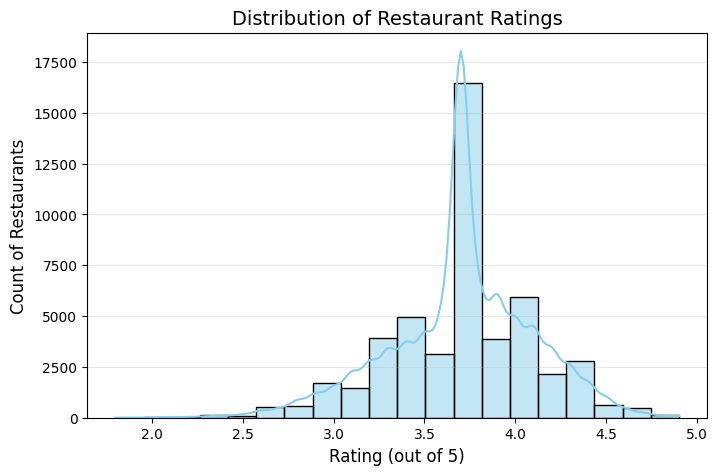

In [41]:
plt.figure(figsize=(8, 5))
# Plotting the distribution of the 'rate' column
sns.histplot(df['rate'], bins=20, kde=True, color='skyblue')

plt.title('Distribution of Restaurant Ratings', fontsize=14)
plt.xlabel('Rating (out of 5)', fontsize=12)
plt.ylabel('Count of Restaurants', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

Q2. What is the most common price range (approx cost for two)?

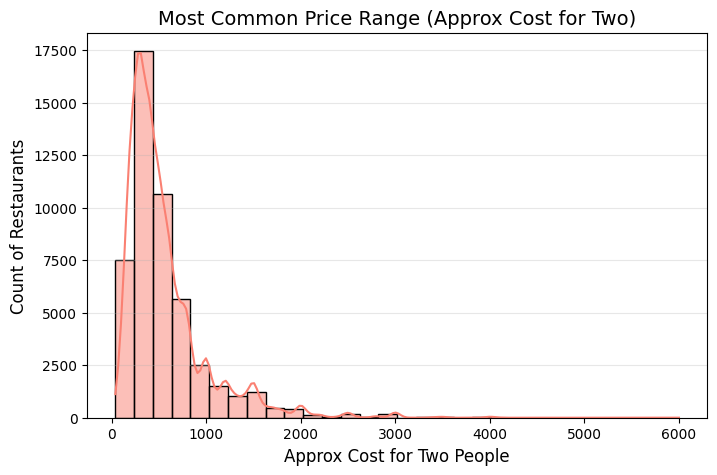

In [42]:
plt.figure(figsize=(8, 5))
# Plotting the distribution of approximation cost
sns.histplot(df['approx_cost(for two people)'], bins=30, kde=True, color='salmon')

plt.title('Most Common Price Range (Approx Cost for Two)', fontsize=14)
plt.xlabel('Approx Cost for Two People', fontsize=12)
plt.ylabel('Count of Restaurants', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

Q3. Which restaurant type appears most in the dataset?

C:\Users\yashv\AppData\Local\Temp\ipykernel_24180\483744594.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_rest_types.values, y=top_rest_types.index, palette='viridis')


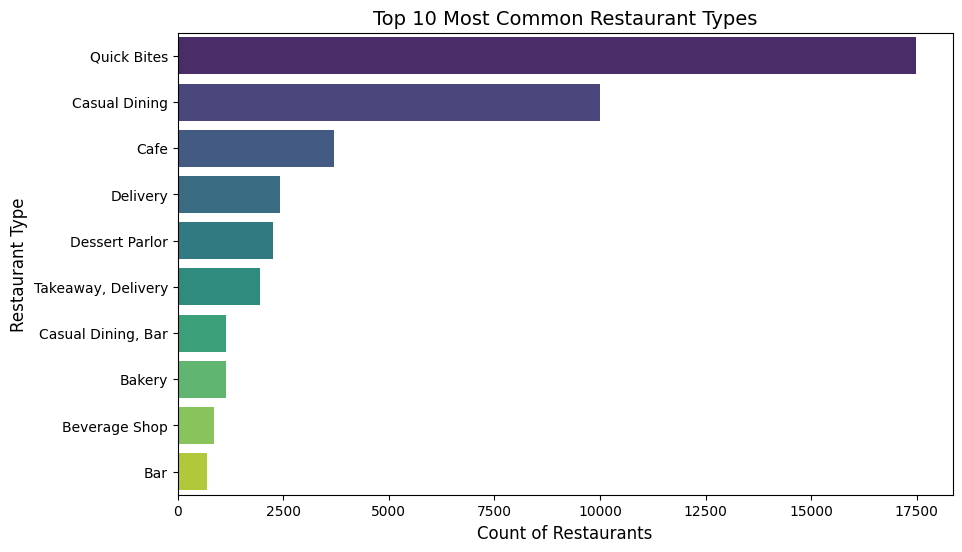

In [43]:
plt.figure(figsize=(10, 6))

# Count the occurrences of each restaurant type and grab the top 10
top_rest_types = df['rest_type'].value_counts().head(10)

# Plot a horizontal bar chart
sns.barplot(x=top_rest_types.values, y=top_rest_types.index, palette='viridis')

plt.title('Top 10 Most Common Restaurant Types', fontsize=14)
plt.xlabel('Count of Restaurants', fontsize=12)
plt.ylabel('Restaurant Type', fontsize=12)
plt.show()

Q4. How many restaurants offer online ordering vs don't?

--- Exact Counts ---
online_order
Yes    29013
No     19998
Name: count, dtype: int64


C:\Users\yashv\AppData\Local\Temp\ipykernel_24180\3923177729.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='online_order', palette='Set2')


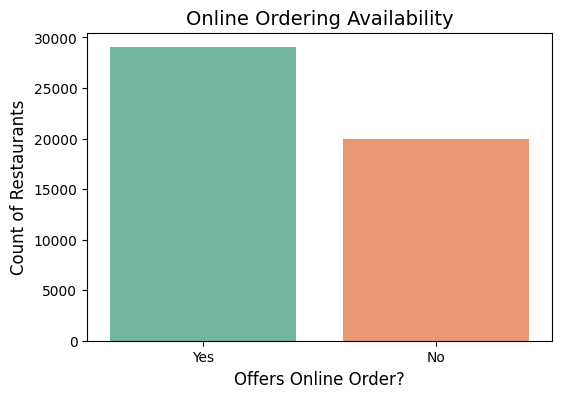

In [44]:
plt.figure(figsize=(6, 4))
# Countplot automatically groups by 'Yes' / 'No' and counts them
sns.countplot(data=df, x='online_order', palette='Set2')

plt.title('Online Ordering Availability', fontsize=14)
plt.xlabel('Offers Online Order?', fontsize=12)
plt.ylabel('Count of Restaurants', fontsize=12)

# Print the exact text counts right above the plot
print("--- Exact Counts ---")
print(df['online_order'].value_counts())
plt.show()

Q5. Does online ordering lead to higher ratings?

C:\Users\yashv\AppData\Local\Temp\ipykernel_24180\1453829302.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='online_order', y='rate', palette='Set2')


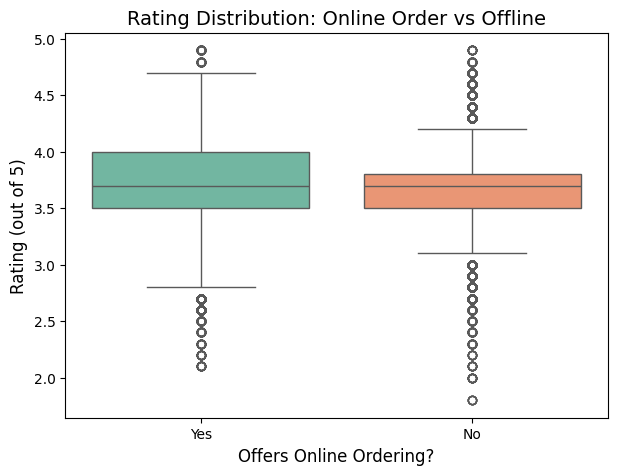

In [45]:
plt.figure(figsize=(7, 5))
# Comparing the rating distribution for online vs offline order
sns.boxplot(data=df, x='online_order', y='rate', palette='Set2')

plt.title('Rating Distribution: Online Order vs Offline', fontsize=14)
plt.xlabel('Offers Online Ordering?', fontsize=12)
plt.ylabel('Rating (out of 5)', fontsize=12)
plt.show()

Q6. Does table booking lead to higher ratings?

C:\Users\yashv\AppData\Local\Temp\ipykernel_24180\2034828852.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='book_table', y='rate', palette='Pastel2')


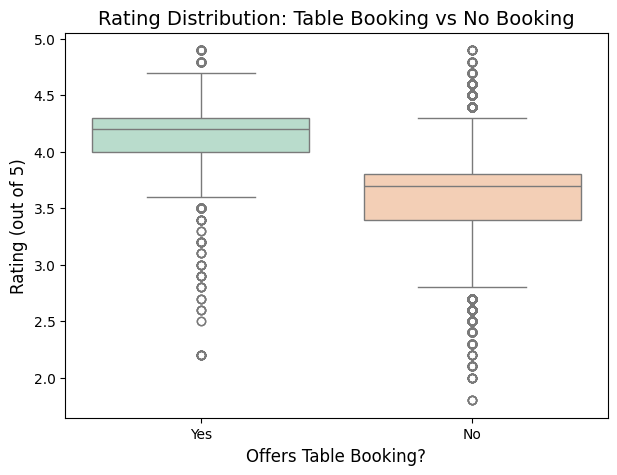

In [46]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='book_table', y='rate', palette='Pastel2')

plt.title('Rating Distribution: Table Booking vs No Booking', fontsize=14)
plt.xlabel('Offers Table Booking?', fontsize=12)
plt.ylabel('Rating (out of 5)', fontsize=12)
plt.show()

Q7. Which location has the most restaurants?

C:\Users\yashv\AppData\Local\Temp\ipykernel_24180\4221071229.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_locations.values, y=top_locations.index, palette='coolwarm')


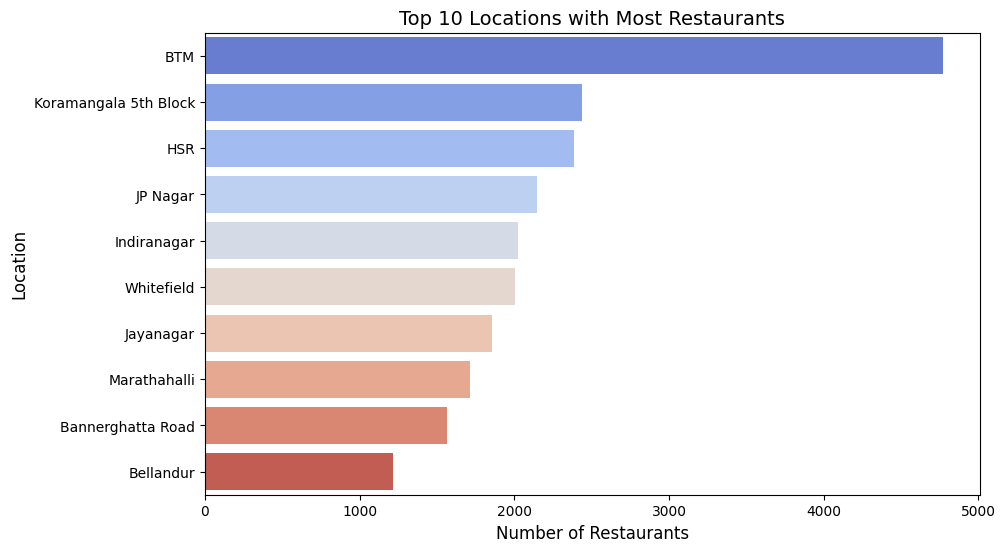

In [47]:
plt.figure(figsize=(10, 6))

top_locations = df['location'].value_counts().head(10)
sns.barplot(x=top_locations.values, y=top_locations.index, palette='coolwarm')

plt.title('Top 10 Locations with Most Restaurants', fontsize=14)
plt.xlabel('Number of Restaurants', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.show()

Q8. Which location has the most affordable average cost?

C:\Users\yashv\AppData\Local\Temp\ipykernel_24180\4127440404.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cheapest_locs.values, y=cheapest_locs.index, palette='Greens')


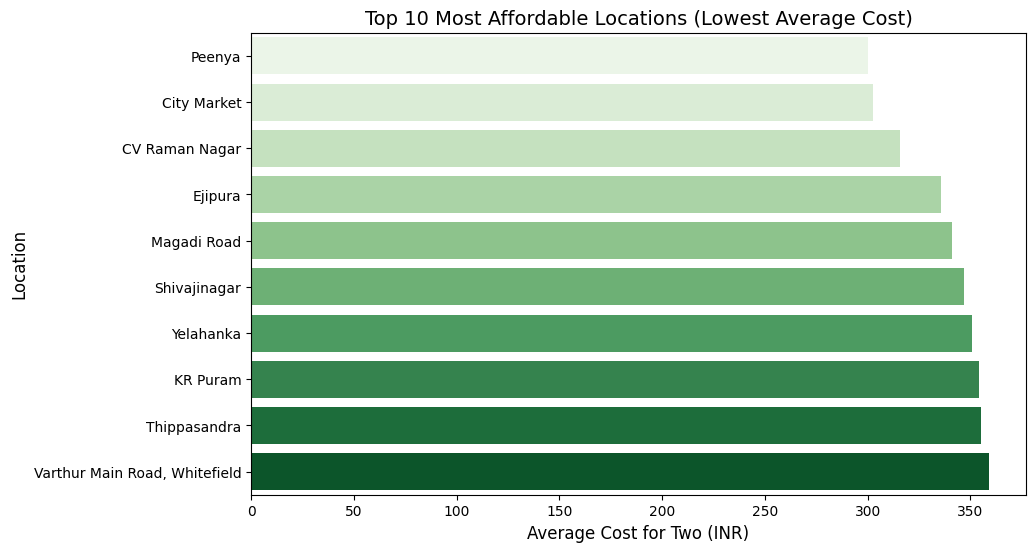

In [48]:
plt.figure(figsize=(10, 6))

# Calculate average cost per location and pick the 10 cheapest
cheapest_locs = df.groupby('location')['approx_cost(for two people)'].mean().sort_values().head(10)

sns.barplot(x=cheapest_locs.values, y=cheapest_locs.index, palette='Greens')

plt.title('Top 10 Most Affordable Locations (Lowest Average Cost)', fontsize=14)
plt.xlabel('Average Cost for Two (INR)', fontsize=12)
plt.ylabel('Location', fontsize=12)
plt.show()

Q9. Do buffet and cafe restaurants rate higher than delivery ones?

C:\Users\yashv\AppData\Local\Temp\ipykernel_24180\3615814742.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='listed_in(type)', y='rate', palette='Set3')


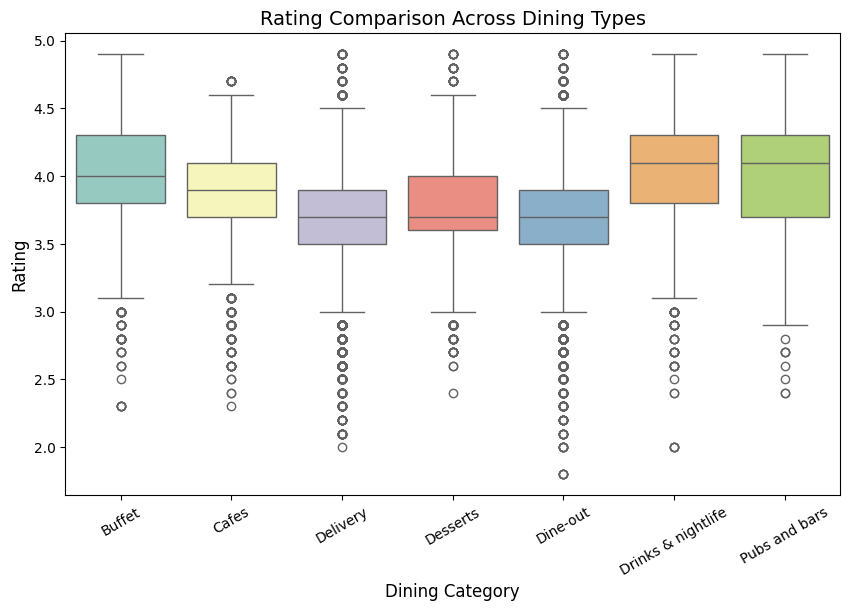

In [49]:
plt.figure(figsize=(10, 6))
# Compare ratings across the broad dining categories
sns.boxplot(data=df, x='listed_in(type)', y='rate', palette='Set3')

plt.title('Rating Comparison Across Dining Types', fontsize=14)
plt.xlabel('Dining Category', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.xticks(rotation=30)
plt.show()

Q10.What proportion of highly rated restaurants (3.5+) offer online ordering?

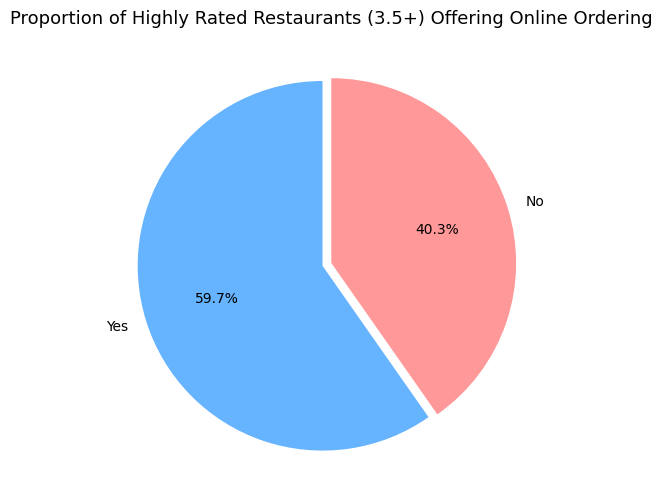

In [50]:
plt.figure(figsize=(6, 6))

# 1. Filter dataset for highly rated restaurants (3.5 and above)
highly_rated_df = df[df['rate'] >= 3.5]

# 2. Get the ratio of Yes vs No for online ordering
online_order_proportion = highly_rated_df['online_order'].value_counts()

# 3. Plot a clean pie chart
plt.pie(
    online_order_proportion, 
    labels=online_order_proportion.index, 
    autopct='%1.1f%%', # Adds percentage numbers inside slices
    colors=['#66b3ff','#ff9999'], 
    startangle=90,
    explode=(0.05, 0) # Slightly separates the first slice for visual pop
)

plt.title('Proportion of Highly Rated Restaurants (3.5+) Offering Online Ordering', fontsize=13)
plt.show()

Splitting Cuisines to get their Counts

In [ ]:
# create exploded dataframe — do NOT overwrite df
df_exploded = df.copy()
df_exploded['cuisines'] = df_exploded['cuisines'].str.split(', ')
df_exploded = df_exploded.explode('cuisines')
df_exploded['cuisines'] = df_exploded['cuisines'].str.strip()

print(df_exploded.shape)          # more rows than original 49011
print(df_exploded['cuisines'].value_counts().head(10))
print(df_exploded.shape)

(120368, 15)
cuisines
North Indian    19433
Chinese         14366
South Indian     7954
Fast Food        7521
Biryani          6138
Continental      5685
Desserts         5569
Cafe             5272
Beverages        4640
Italian          3343
Name: count, dtype: int64
(120368, 15)


Q11. Which area has the highest rated restaurants and for which cuisines?

In [55]:
# Part A — top 10 locations by average rating
location_rating = df_exploded.groupby('location')['rate'].mean().round(2)
location_rating = location_rating.sort_values(ascending=False).head(10)
print(location_rating)

location
Lavelle Road             4.16
St. Marks Road           4.09
Koramangala 5th Block    4.05
Koramangala 3rd Block    4.03
Church Street            4.01
Cunningham Road          3.99
Sankey Road              3.97
Koramangala 4th Block    3.97
MG Road                  3.91
Residency Road           3.91
Name: rate, dtype: float64


In [56]:
# updated with your actual top 3 locations
top_locations = ['Lavelle Road', 'St. Marks Road', 'Koramangala 5th Block']

cuisine_by_location = df_exploded[
    df_exploded['location'].isin(top_locations)
].groupby(['location', 'cuisines'])['rate'].mean().round(2)

cuisine_by_location = cuisine_by_location.sort_values(ascending=False)
print(cuisine_by_location.groupby('location').head(5))

location               cuisines     
Lavelle Road           Juices           4.60
St. Marks Road         Japanese         4.54
                       Indonesian       4.54
                       Singaporean      4.54
                       Malaysian        4.54
                       Korean           4.54
Koramangala 5th Block  Mediterranean    4.51
                       Sushi            4.50
                       Korean           4.41
Lavelle Road           Parsi            4.41
                       Japanese         4.40
                       Kebab            4.40
                       Modern Indian    4.40
Koramangala 5th Block  Sri Lankan       4.40
                       Burmese          4.40
Name: rate, dtype: float64


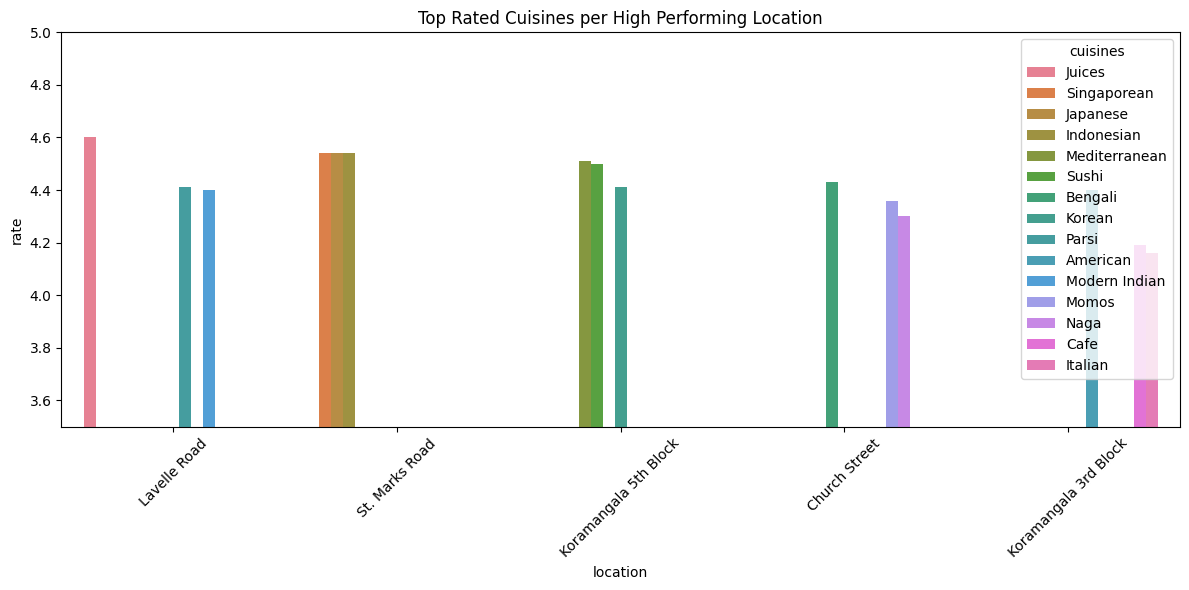

In [57]:
top_locs = ['Lavelle Road', 'St. Marks Road', 'Koramangala 5th Block',
            'Koramangala 3rd Block', 'Church Street']

top_cuisine_location = df_exploded.groupby(
    ['location', 'cuisines'])['rate'].mean().round(2).reset_index()

plot_data = top_cuisine_location[
    top_cuisine_location['location'].isin(top_locs)
]

top_per_loc = plot_data.sort_values(
    'rate', ascending=False).groupby('location').head(3)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_per_loc, x='location', y='rate', hue='cuisines')
plt.title('Top Rated Cuisines per High Performing Location')
plt.xticks(rotation=45)
plt.ylim(3.5, 5.0)
plt.tight_layout()
plt.show()

Q12. Which rest_type serves which cuisine most — for cafes, buffets, delivery?

In [58]:
# Part A — which rest_type gets most votes overall (reminder from Q14)
# now we go deeper — which cuisines dominate each rest_type

target_types = ['Cafes', 'Buffet', 'Delivery']

cuisine_resttype = df_exploded[
    df_exploded['rest_type'].isin(target_types)
].groupby(['rest_type', 'cuisines'])['votes'].sum().reset_index()

# top 5 cuisines per rest_type by votes
top_cuisines_per_type = cuisine_resttype.sort_values(
    'votes', ascending=False).groupby('rest_type').head(5)

print(top_cuisines_per_type.sort_values(['rest_type', 'votes'], ascending=[True, False]))

   rest_type      cuisines   votes
39  Delivery  North Indian  126348
11  Delivery       Biryani   93215
15  Delivery       Chinese   68229
16  Delivery   Continental   59301
22  Delivery  Healthy Food   54313


In [60]:
# corrected spellings
target_types = ['Cafe', 'Buffet', 'Delivery', 'Quick Bites', 'Casual Dining']

cuisine_resttype = df_exploded[
    df_exploded['rest_type'].isin(target_types)
].groupby(['rest_type', 'cuisines'])['votes'].sum().reset_index()

top_cuisines_per_type = cuisine_resttype.sort_values(
    'votes', ascending=False).groupby('rest_type').head(5)

print(top_cuisines_per_type.sort_values(
    ['rest_type', 'votes'], ascending=[True, False]))

         rest_type      cuisines    votes
8             Cafe          Cafe  1449100
7             Cafe        Burger   642200
11            Cafe   Continental   625068
18            Cafe       Italian   606893
0             Cafe      American   397157
104  Casual Dining  North Indian  2645544
65   Casual Dining       Chinese  1898013
100  Casual Dining       Mughlai   709667
59   Casual Dining       Biryani   704342
116  Casual Dining  South Indian   679852
169       Delivery  North Indian   126348
141       Delivery       Biryani    93215
145       Delivery       Chinese    68229
146       Delivery   Continental    59301
152       Delivery  Healthy Food    54313
241    Quick Bites  North Indian   598411
209    Quick Bites     Fast Food   440001
203    Quick Bites       Chinese   412584
250    Quick Bites  South Indian   327626
196    Quick Bites       Biryani   187673


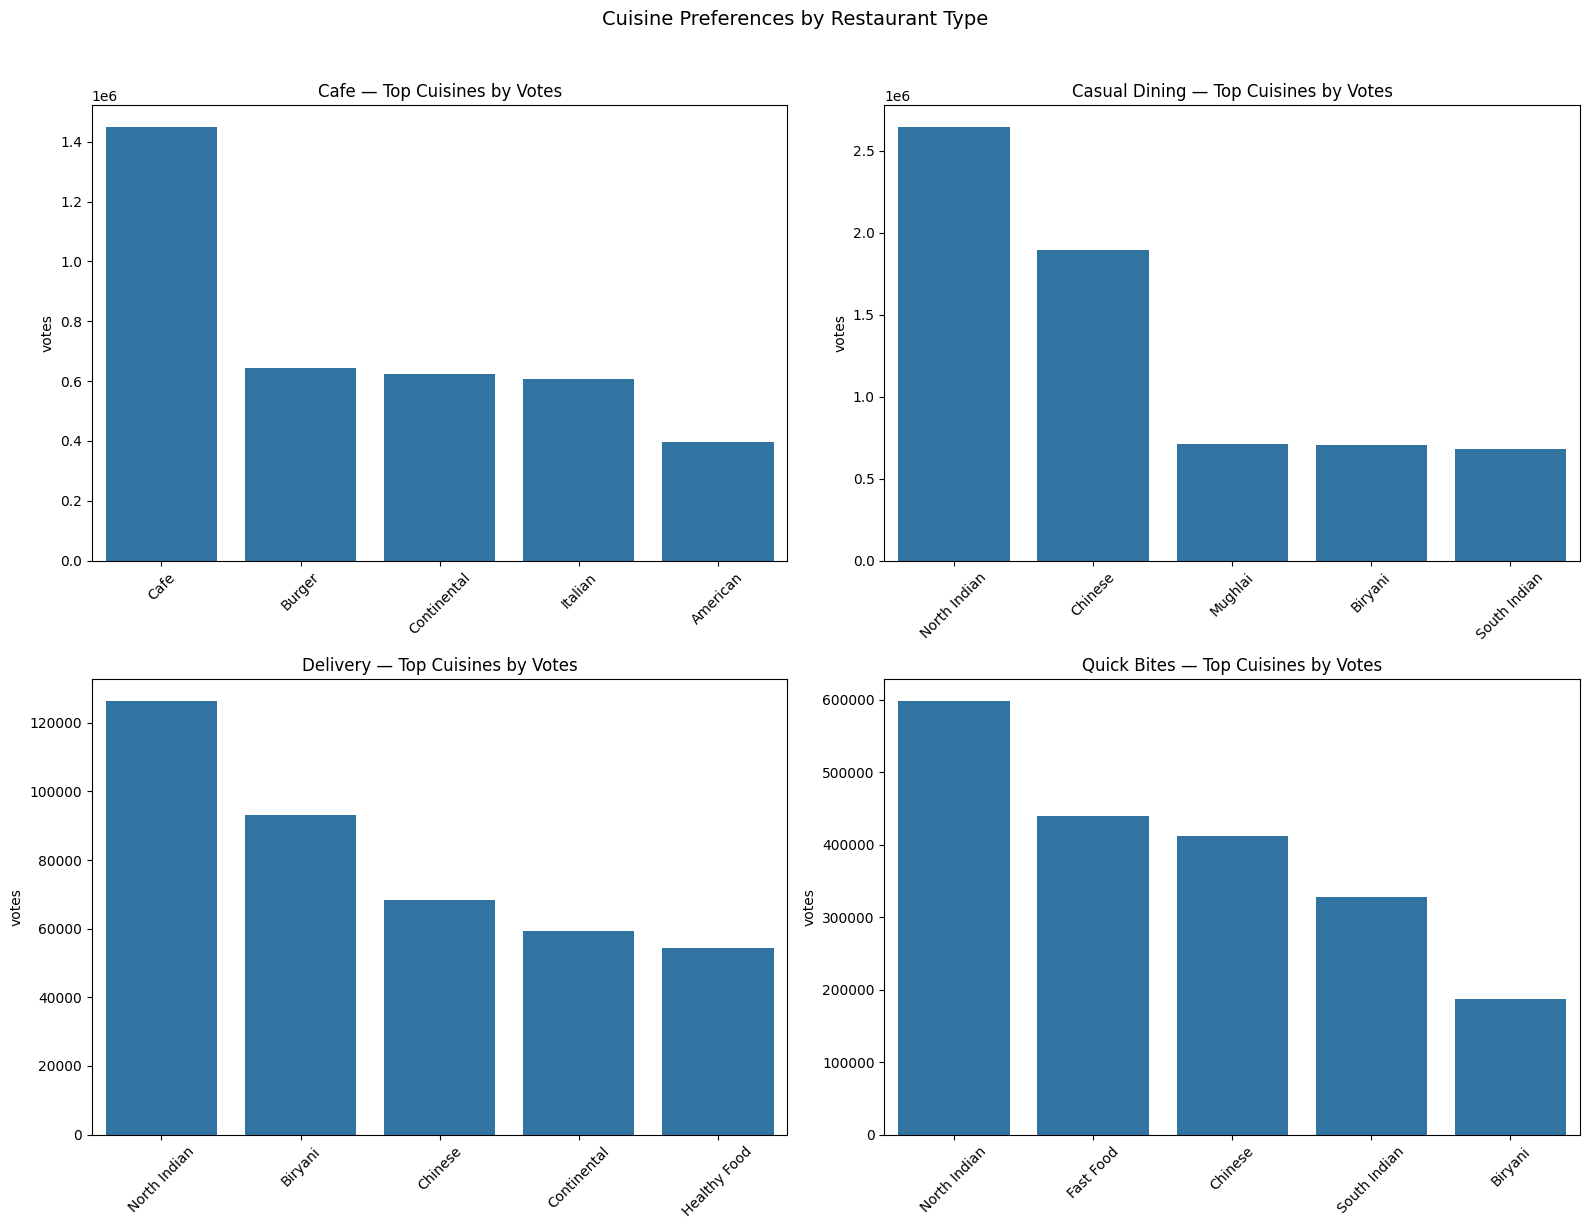

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, rtype in enumerate(['Cafe', 'Casual Dining', 'Delivery', 'Quick Bites']):
    data = top_cuisines_per_type[top_cuisines_per_type['rest_type'] == rtype]
    sns.barplot(data=data, x='cuisines', y='votes', ax=axes[i])
    axes[i].set_title(f'{rtype} — Top Cuisines by Votes')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Cuisine Preferences by Restaurant Type', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()

Q13. Which listed_in(type) dominates which location?Q21 — Which listed_in(type) dominates which location?

In [62]:
# Part A — count of each listed_in(type) per location
listed_location = df.groupby(
    ['location', 'listed_in(type)'])['name'].count().reset_index()
listed_location.columns = ['location', 'listed_type', 'count']

# top listed type per location
top_listed_per_location = listed_location.sort_values(
    'count', ascending=False).groupby('location').head(1)

print(top_listed_per_location.sort_values('count', ascending=False).head(15))

                  location listed_type  count
2                      BTM    Delivery   2887
126                    HSR    Delivery   1635
164               JP Nagar    Delivery   1101
150            Indiranagar    Delivery   1073
236  Koramangala 5th Block    Delivery   1050
175              Jayanagar    Delivery   1003
454             Whitefield    Delivery    979
299           Marathahalli    Delivery    915
21       Bannerghatta Road    Delivery    812
209  Koramangala 1st Block    Delivery    673
41               Bellandur    Delivery    593
384          Sarjapur Road    Delivery    535
107        Electronic City    Delivery    531
55            Brigade Road    Delivery    504
243  Koramangala 6th Block    Delivery    502


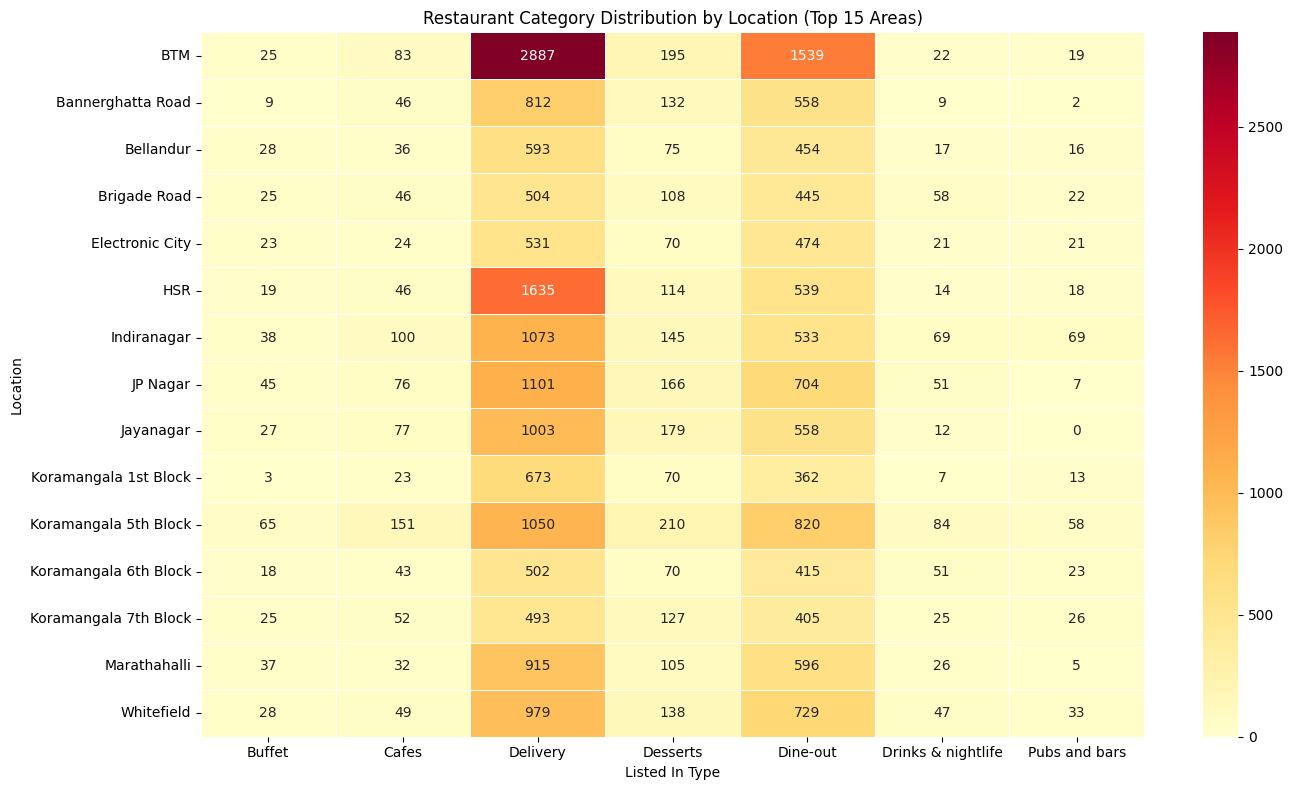

In [66]:
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_filtered, 
            annot=True, 
            fmt='.0f',        # ← changed from 'd' to '.0f'
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('Restaurant Category Distribution by Location (Top 15 Areas)')
plt.xlabel('Listed In Type')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

Same without Delivery

In [64]:
# exclude Delivery to see the real character of each neighbourhood
listed_location_nodelivery = df[
    df['listed_in(type)'] != 'Delivery'
].groupby(['location', 'listed_in(type)'])['name'].count().reset_index()
listed_location_nodelivery.columns = ['location', 'listed_type', 'count']

top_listed_nodelivery = listed_location_nodelivery.sort_values(
    'count', ascending=False).groupby('location').head(1)

print(top_listed_nodelivery.sort_values('count', ascending=False).head(15))

                  location listed_type  count
3                      BTM    Dine-out   1539
192  Koramangala 5th Block    Dine-out    820
367             Whitefield    Dine-out    729
136               JP Nagar    Dine-out    704
244           Marathahalli    Dine-out    596
144              Jayanagar    Dine-out    558
19       Bannerghatta Road    Dine-out    558
105                    HSR    Dine-out    539
124            Indiranagar    Dine-out    533
89         Electronic City    Dine-out    474
36               Bellandur    Dine-out    454
48            Brigade Road    Dine-out    445
198  Koramangala 6th Block    Dine-out    415
204  Koramangala 7th Block    Dine-out    405
169  Koramangala 1st Block    Dine-out    362


Location where Dine out doesnt dominate?

In [68]:
# find locations where something OTHER than Dine-out dominates
not_dineout = top_listed_nodelivery[
    top_listed_nodelivery['listed_type'] != 'Dine-out'
]
print(not_dineout.sort_values('count', ascending=False))

          location listed_type  count
83  East Bangalore    Desserts      1


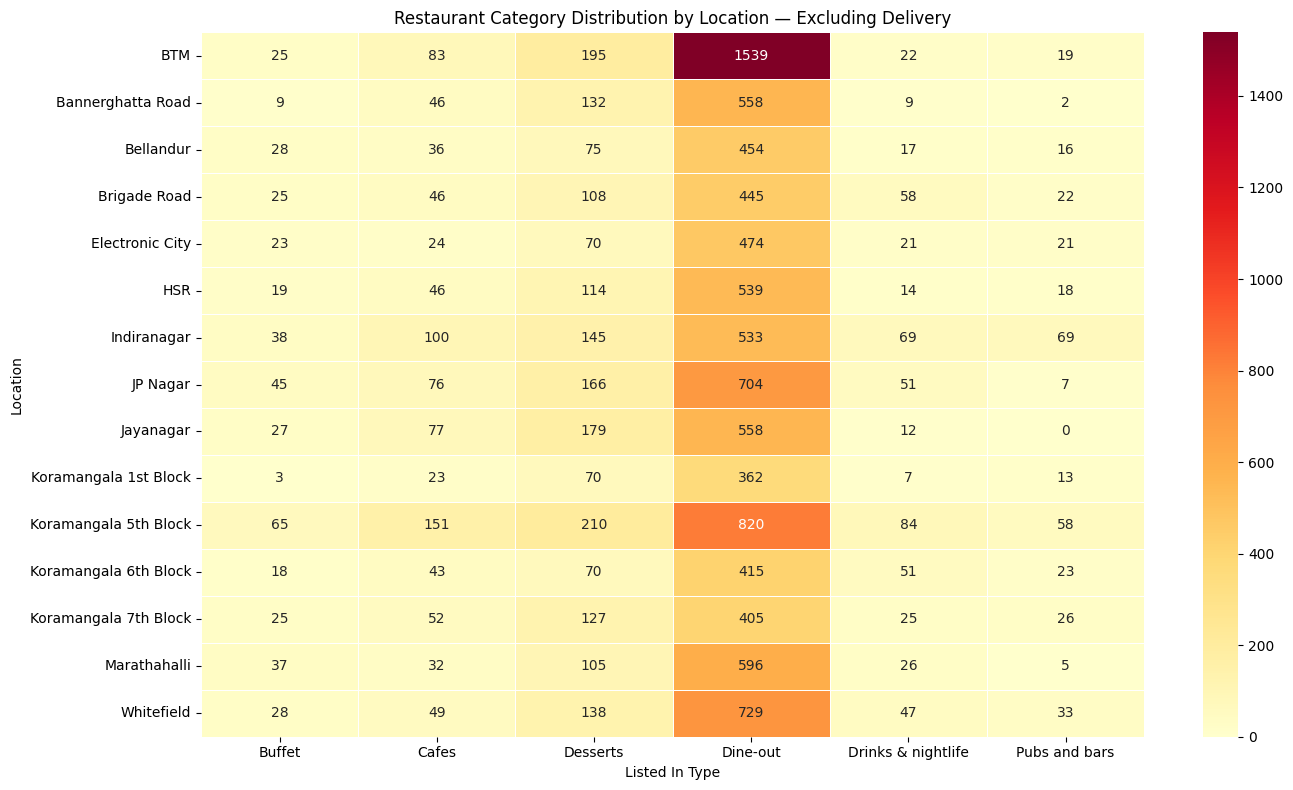

In [69]:
pivot2 = listed_location_nodelivery.pivot_table(
    index='location',
    columns='listed_type',
    values='count',
    fill_value=0)

top_15_locs = df['location'].value_counts().head(15).index
pivot_filtered2 = pivot2.loc[pivot2.index.isin(top_15_locs)]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_filtered2,
            annot=True,
            fmt='.0f',
            cmap='YlOrRd',
            linewidths=0.5)
plt.title('Restaurant Category Distribution by Location — Excluding Delivery')
plt.xlabel('Listed In Type')
plt.ylabel('Location')
plt.tight_layout()
plt.show()

Q14. Which price range in which location gets the highest votes?

In [70]:
# create price buckets first
df['cost_bucket'] = pd.cut(
    df['approx_cost(for two people)'],
    bins=[0, 200, 500, 1000, 2000, 10000],
    labels=['Budget(0-200)', 'Affordable(200-500)', 
            'Mid-range(500-1000)', 'Premium(1000-2000)', 
            'Luxury(2000+)'])

# votes per cost bucket per location
cost_location_votes = df.groupby(
    ['location', 'cost_bucket'],
    observed=True)['votes'].mean().round(0).reset_index()

# top performing bucket per location
top_bucket_per_loc = cost_location_votes.sort_values(
    'votes', ascending=False).groupby('location').head(1)

print(top_bucket_per_loc.sort_values('votes', ascending=False).head(15))

                  location         cost_bucket   votes
303         St. Marks Road       Luxury(2000+)  5277.0
333             Whitefield       Luxury(2000+)  2775.0
206           Malleshwaram       Luxury(2000+)  2590.0
282          Sarjapur Road  Premium(1000-2000)  2466.0
231       Old Airport Road  Premium(1000-2000)  2229.0
167  Koramangala 5th Block  Premium(1000-2000)  2206.0
210           Marathahalli  Premium(1000-2000)  2033.0
48           Church Street  Premium(1000-2000)  2016.0
177  Koramangala 7th Block  Premium(1000-2000)  1958.0
106            Indiranagar  Premium(1000-2000)  1690.0
271         Sahakara Nagar  Premium(1000-2000)  1607.0
151  Koramangala 1st Block  Premium(1000-2000)  1554.0
189           Lavelle Road       Luxury(2000+)  1535.0
59         Cunningham Road  Premium(1000-2000)  1383.0
36            Brigade Road  Premium(1000-2000)  1294.0


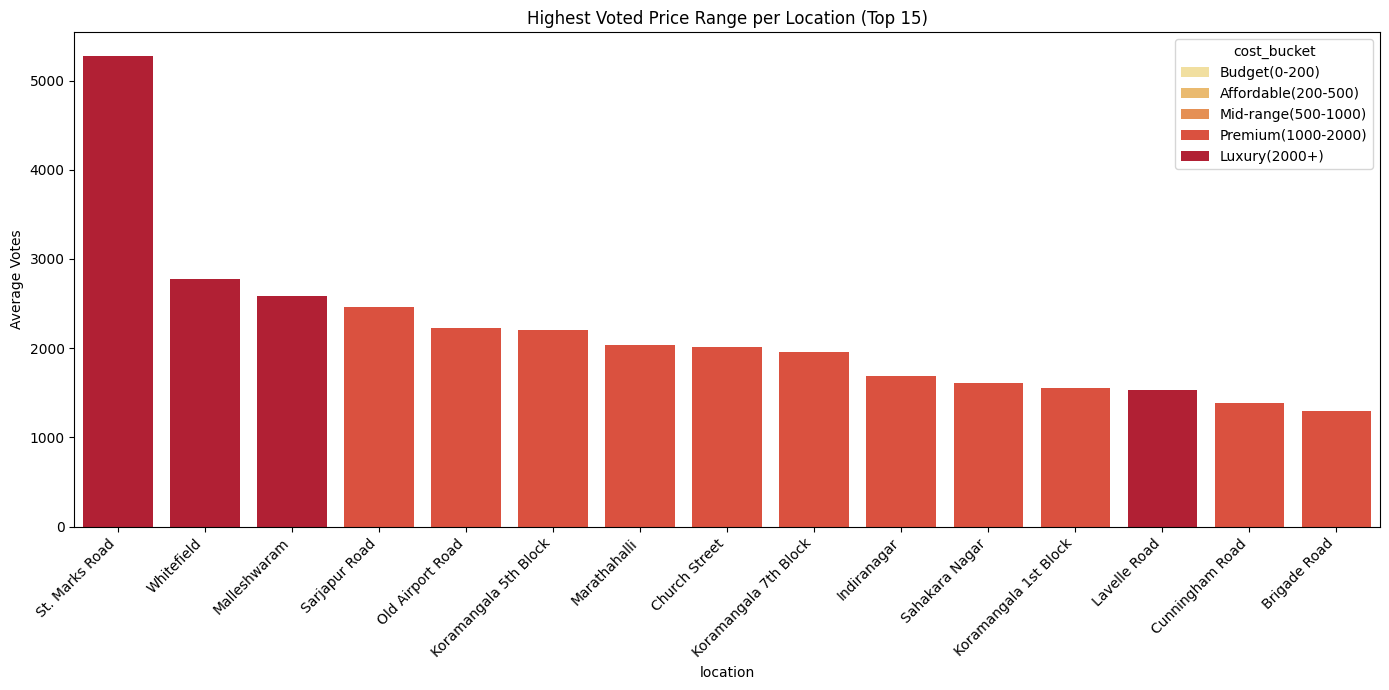

In [71]:
plt.figure(figsize=(14, 7))
sns.barplot(data=top_bucket_per_loc.sort_values('votes', ascending=False).head(15),
            x='location', y='votes', hue='cost_bucket',
            palette='YlOrRd')
plt.title('Highest Voted Price Range per Location (Top 15)')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Average Votes')
plt.tight_layout()
plt.show()

Q14. Underserved areas: high demand, low restaurant count, which cuisines missing?

In [72]:
# Part A — calculate supply vs demand per location
location_stats = df.groupby('location').agg(
    restaurant_count=('name', 'count'),
    avg_votes=('votes', 'mean'),
    avg_rating=('rate', 'mean')
).round(2).reset_index()

# calculate demand to supply ratio
# high ratio = high demand relative to supply = underserved
location_stats['demand_supply_ratio'] = (
    location_stats['avg_votes'] / 
    location_stats['restaurant_count']
).round(2)

print(location_stats.sort_values(
    'demand_supply_ratio', ascending=False).head(15))

                 location  restaurant_count  avg_votes  avg_rating  \
68   Rajarajeshwari Nagar                 2     366.00        3.85   
11      Central Bangalore                 3     383.33        3.60   
88         West Bangalore                 5     222.00        3.50   
61        North Bangalore                 7     228.71        3.61   
75            Sankey Road                27     237.44        3.96   
50          Langford Town                27     195.59        3.81   
39                Kengeri                 9      50.67        3.72   
91              Yelahanka                 6      31.50        3.65   
64                 Peenya                 1       5.00        3.20   
72         Sadashiv Nagar                63     313.13        3.83   
63        Old Madras Road                20      80.00        3.18   
43  Koramangala 3rd Block               196     626.73        4.00   
23                 Hebbal                12      37.50        3.63   
40            Korama

In [73]:
# Part B — identify underserved locations
underserved = location_stats[
    (location_stats['demand_supply_ratio'] > 10) &
    (location_stats['restaurant_count'] < 50)
].sort_values('demand_supply_ratio', ascending=False)

print("Underserved locations:")
print(underserved[['location', 'restaurant_count', 
                    'avg_votes', 'demand_supply_ratio']])

Underserved locations:
                location  restaurant_count  avg_votes  demand_supply_ratio
68  Rajarajeshwari Nagar                 2     366.00               183.00
11     Central Bangalore                 3     383.33               127.78
88        West Bangalore                 5     222.00                44.40
61       North Bangalore                 7     228.71                32.67


In [74]:
# Part C — what cuisines exist in underserved areas
underserved_locs = underserved['location'].tolist()

existing_cuisines = df_exploded[
    df_exploded['location'].isin(underserved_locs)
].groupby(['location', 'cuisines'])['votes'].sum().reset_index()

top_existing = existing_cuisines.sort_values(
    'votes', ascending=False).groupby('location').head(3)

print("\nTop cuisines currently serving underserved areas:")
print(top_existing.sort_values(['location', 'votes'], ascending=[True, False]))


Top cuisines currently serving underserved areas:
                location      cuisines  votes
7      Central Bangalore  Healthy Food   1150
3      Central Bangalore        Burger   1150
2      Central Bangalore       Biryani   1150
15       North Bangalore       Chinese   1601
19       North Bangalore  North Indian   1601
13       North Bangalore       Biryani   1593
25  Rajarajeshwari Nagar          Thai    679
22  Rajarajeshwari Nagar       Chinese    679
23  Rajarajeshwari Nagar       Italian     53
33        West Bangalore  Healthy Food   1110
28        West Bangalore       Biryani   1072
29        West Bangalore        Burger   1072


In [75]:
# Part D — what cuisines are MISSING 
# compare against city-wide top cuisines
citywide_top_cuisines = df_exploded['cuisines'].value_counts().head(10).index.tolist()

for loc in underserved_locs:
    loc_cuisines = df_exploded[
        df_exploded['location'] == loc]['cuisines'].unique().tolist()
    missing = [c for c in citywide_top_cuisines if c not in loc_cuisines]
    print(f"\n{loc}:")
    print(f"  Missing top cuisines: {missing}")


Rajarajeshwari Nagar:
  Missing top cuisines: ['North Indian', 'South Indian', 'Fast Food', 'Biryani', 'Continental', 'Desserts', 'Cafe', 'Beverages']

Central Bangalore:
  Missing top cuisines: ['South Indian', 'Desserts', 'Cafe', 'Beverages']

West Bangalore:
  Missing top cuisines: ['South Indian', 'Desserts', 'Cafe', 'Beverages']

North Bangalore:
  Missing top cuisines: ['South Indian', 'Fast Food', 'Desserts', 'Cafe', 'Beverages']


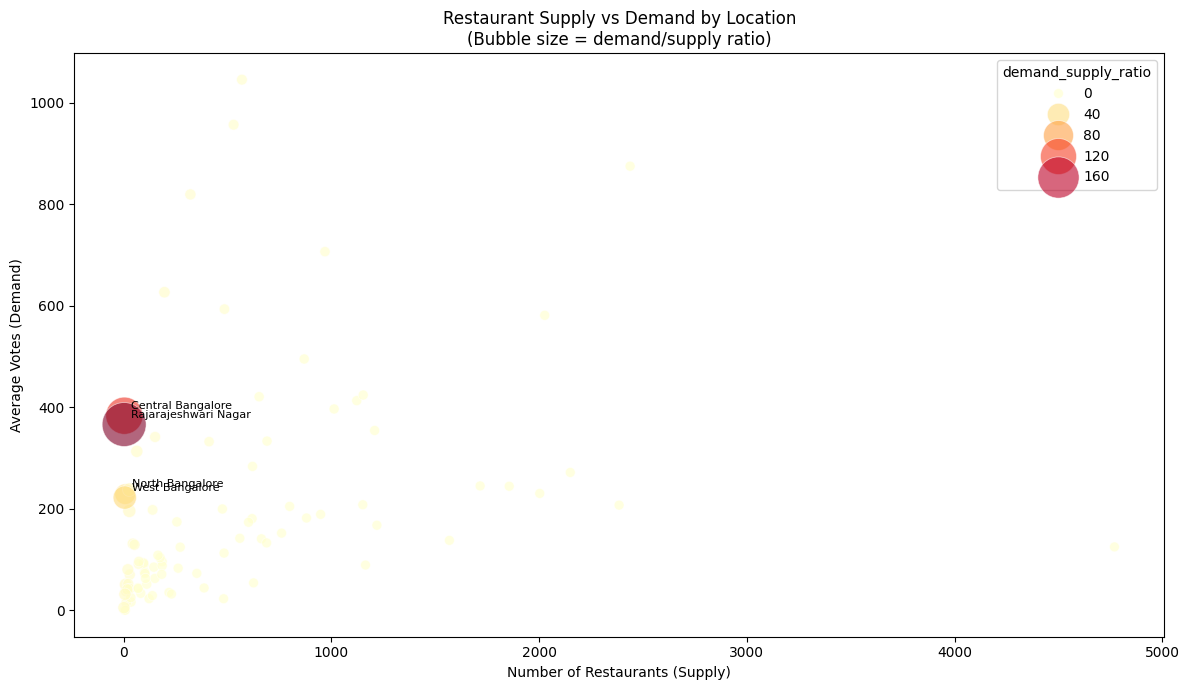

In [76]:
# Part E — visualize supply vs demand
plt.figure(figsize=(12, 7))
sns.scatterplot(data=location_stats,
                x='restaurant_count',
                y='avg_votes',
                size='demand_supply_ratio',
                sizes=(50, 1000),
                alpha=0.6,
                hue='demand_supply_ratio',
                palette='YlOrRd')

# label the underserved ones
for _, row in underserved.iterrows():
    plt.annotate(row['location'],
                xy=(row['restaurant_count'], row['avg_votes']),
                xytext=(5, 5),
                textcoords='offset points',
                fontsize=8)

plt.title('Restaurant Supply vs Demand by Location\n(Bubble size = demand/supply ratio)')
plt.xlabel('Number of Restaurants (Supply)')
plt.ylabel('Average Votes (Demand)')
plt.tight_layout()
plt.show()